## Exercise 8 training SVC and SGDClassifier on linear datasets

In [31]:
#create the data
import numpy as np
from matplotlib import pyplot as plt


In [36]:
m = 100
X0 = np.linspace(-3, 3, m)
X1 = np.zeros(shape = X0.shape)
y = np.zeros(shape = X0.shape)
for i in range(len(X0)):
    if X0[i] >= 0:
        X1[i] = X0[i] + np.random.randn()*3 + 5
        y[i] = 1
    else:
        X1[i] = X0[i] + np.random.randn()*3 - 5
X = np.c_[X0, X1]



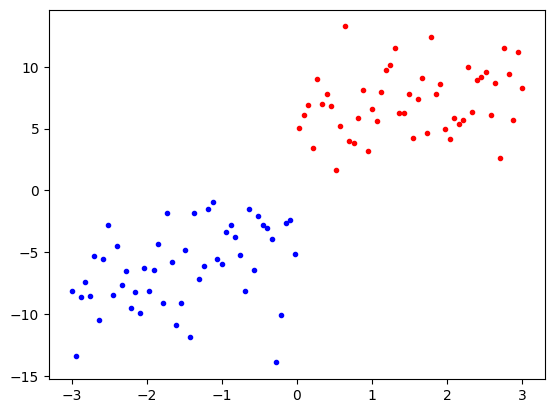

In [37]:
plt.plot(X[y == 0, 0], X[y == 0, 1], 'b.')
plt.plot(X[y == 1, 0], X[y == 1, 1], 'r.')
plt.show()

In [42]:
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
C = 1
svc_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LinearSVC(C = 1, loss = 'hinge'))
])
svc_clf.fit(X, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', LinearSVC(C=1, loss='hinge'))])

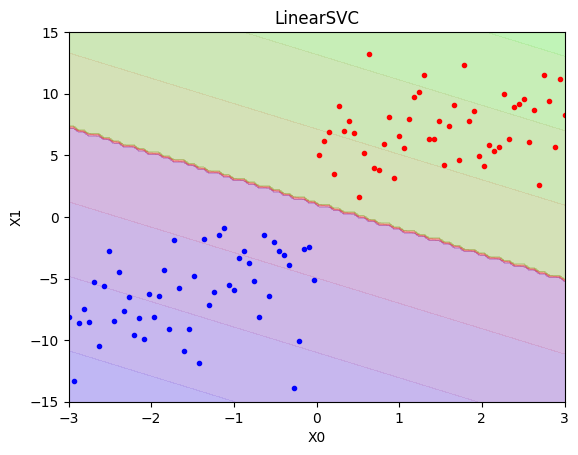

In [46]:
# visualization code is borrowed from the notebooks of the author
def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    y_decision = clf.decision_function(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, cmap=plt.cm.brg, alpha=0.2)
    plt.contourf(x0, x1, y_decision, cmap=plt.cm.brg, alpha=0.1)

plot_predictions(svc_clf, [-3, 3, -15, 15])
plt.plot(X[y == 0, 0], X[y == 0, 1], 'b.')
plt.plot(X[y == 1, 0], X[y == 1, 1], 'r.')
plt.title('LinearSVC')
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()


In [47]:
from sklearn.linear_model import SGDClassifier

sgd_clf = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', SGDClassifier(alpha = 1/(m*C), loss = 'hinge'))
])

sgd_clf.fit(X, y)


Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', SGDClassifier(alpha=0.01))])

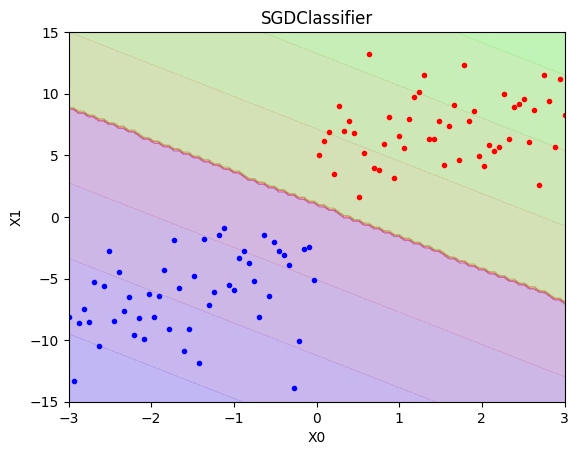

In [48]:
plot_predictions(sgd_clf, [-3, 3, -15, 15])
plt.plot(X[y == 0, 0], X[y == 0, 1], 'b.')
plt.plot(X[y == 1, 0], X[y == 1, 1], 'r.')
plt.title('SGDClassifier')
plt.xlabel('X0')
plt.ylabel('X1')
plt.show()